In [ ]:
# Task 03  ·  Correlation Analysis  [Hard]
# Build a dataset with multiple variables and find meaningful correlations between them
# Goal Create a synthetic student dataset with multiple columns, then perform a full correlation analysis.
# 1 Create a CSV with 50 students — columns: name, study_hours, sleep_hours, attendance_pct, score, passed
# 2 Make the data realistic — students who study more should generally score higher (add some noise)
# 3 Load into Pandas and run the full EDA checklist first
# 4 Calculate df.corr() — print the full correlation matrix
# 5 Create a seaborn heatmap — annotate with values, use 'coolwarm' colormap
# 6 Find the top 3 strongest correlations and the top 3 weakest — print them with explanation
# 7 Plot scatter plots for the 2 most correlated pairs — add a regression line using sns.regplot()
# 8 Answer in comments: Does more study always mean higher score? What does the data actually say?
# Deliverable: students.csv + heatmap.png + 2 scatter
# plots + written analysis
# Bonus: Use sns.pairplot(hue='passed') — do
# passed/failed students form clear clusters?


## Correlation Analysis of Student Performance

In [ ]:
# Ensure libraries are installed
!pip install pandas numpy seaborn matplotlib --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Create a Synthetic Student Dataset

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

num_students = 50

# Generate names (simple unique identifiers)
names = [f'Student_{i+1}' for i in range(num_students)]

# Generate study_hours (e.g., 1 to 10 hours)
study_hours = np.random.uniform(1, 10, num_students).round(1)

# Generate sleep_hours (e.g., 5 to 9 hours)
sleep_hours = np.random.uniform(5, 9, num_students).round(1)

# Generate attendance_pct (e.g., 70% to 100%)
attendance_pct = np.random.uniform(70, 100, num_students).round(1)

# Generate score: study_hours generally lead to higher scores, with some noise
# Base score influenced by study_hours, sleep_hours, and attendance_pct
score_base = (study_hours * 5) + (sleep_hours * 3) + (attendance_pct * 0.5)
noise = np.random.normal(0, 10, num_students) # Add random noise
scores = (score_base + noise).round(0)

# Ensure scores are within a reasonable range (0-100)
scores = np.clip(scores, 0, 100)

# Determine if student passed (e.g., score > 60)
passed = ['Yes' if s > 60 else 'No' for s in scores]

# Create DataFrame
data = {
    'name': names,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'attendance_pct': attendance_pct,
    'score': scores,
    'passed': passed
}
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('students.csv', index=False)

print("Synthetic student dataset created and saved to 'students.csv'")
display(df.head())

Synthetic student dataset created and saved to 'students.csv'


,name,study_hours,sleep_hours,attendance_pct,score,passed
0,Student_1,4.4,8.9,70.9,82.0,Yes
1,Student_2,9.6,8.1,89.1,100.0,Yes
2,Student_3,7.6,8.8,79.4,100.0,Yes
3,Student_4,6.4,8.6,85.3,89.0,Yes
4,Student_5,2.4,7.4,97.2,94.0,Yes


### 2. Exploratory Data Analysis (EDA)

In [ ]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            50 non-null     object 
 1   study_hours     50 non-null     float64
 2   sleep_hours     50 non-null     float64
 3   attendance_pct  50 non-null     float64
 4   score           50 non-null     float64
 5   passed          50 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.5+ KB

Descriptive Statistics:


,study_hours,sleep_hours,attendance_pct,score
count,50.000000,50.000000,50.000000,50.000000
mean,5.016000,6.982000,84.346000,86.160000
std,2.604342,1.226192,8.930393,12.623852
min,1.200000,5.000000,70.200000,51.000000
25%,2.700000,5.875000,77.525000,78.000000
50%,4.950000,7.050000,82.650000,89.500000
75%,6.875000,8.100000,93.750000,98.000000
max,9.700000,8.900000,99.200000,100.000000


### 3. Correlation Analysis

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.drop('name', axis=1).corr(numeric_only=True)
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,study_hours,sleep_hours,attendance_pct,score
study_hours,1.000000,0.061826,-0.120606,0.652387
sleep_hours,0.061826,1.000000,-0.111353,0.289583
attendance_pct,-0.120606,-0.111353,1.000000,0.176380
score,0.652387,0.289583,0.176380,1.000000


### 4. Visualize Correlation with a Heatmap

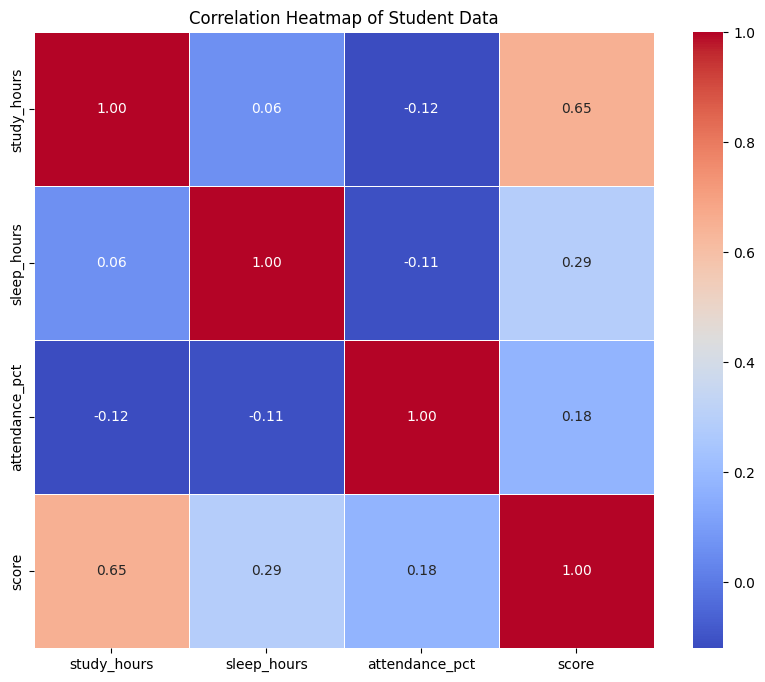

Correlation heatmap saved as 'heatmap.png'


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Student Data')
plt.savefig('heatmap.png')
plt.show()
print("Correlation heatmap saved as 'heatmap.png'")

### 5. Find Strongest and Weakest Correlations

In [ ]:
# Get unique correlation pairs, excluding self-correlation and duplicates
corr_pairs = correlation_matrix.stack().reset_index()
corr_pairs.columns = ['Variable A', 'Variable B', 'Correlation']

# Filter out self-correlations (where A == B)
corr_pairs = corr_pairs[corr_pairs['Variable A'] != corr_pairs['Variable B']]

# Remove duplicate pairs (e.g., (A,B) and (B,A))
corr_pairs['sorted_vars'] = corr_pairs.apply(lambda row: tuple(sorted([row['Variable A'], row['Variable B']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=['sorted_vars'])
corr_pairs = corr_pairs.drop(columns=['sorted_vars'])

# Sort by absolute correlation for strongest/weakest
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()

# Top 3 strongest correlations
strongest_correlations = corr_pairs.nlargest(3, 'Abs Correlation')
print("\nTop 3 Strongest Correlations:")
display(strongest_correlations)

# Top 3 weakest correlations (closest to 0)
weakest_correlations = corr_pairs.nsmallest(3, 'Abs Correlation')
print("\nTop 3 Weakest Correlations:")
display(weakest_correlations)

print("\nExplanation of strongest correlations:")
for index, row in strongest_correlations.iterrows():
    print(f"- {row['Variable A']} and {row['Variable B']}: Correlation = {row['Correlation']:.2f}. This indicates a strong {('positive' if row['Correlation'] > 0 else 'negative')} linear relationship. For example, as {row['Variable A']} increases, {row['Variable B']} tends to {('increase' if row['Correlation'] > 0 else 'decrease')}.")

print("\nExplanation of weakest correlations:")
for index, row in weakest_correlations.iterrows():
    print(f"- {row['Variable A']} and {row['Variable B']}: Correlation = {row['Correlation']:.2f}. This indicates a very weak or no linear relationship. Changes in {row['Variable A']} are not strongly associated with changes in {row['Variable B']}.")


Top 3 Strongest Correlations:


,Variable A,Variable B,Correlation,Abs Correlation
3,study_hours,score,0.652387,0.652387
7,sleep_hours,score,0.289583,0.289583
11,attendance_pct,score,0.176380,0.176380



Top 3 Weakest Correlations:


,Variable A,Variable B,Correlation,Abs Correlation
1,study_hours,sleep_hours,0.061826,0.061826
6,sleep_hours,attendance_pct,-0.111353,0.111353
2,study_hours,attendance_pct,-0.120606,0.120606



Explanation of strongest correlations:
- study_hours and score: Correlation = 0.65. This indicates a strong positive linear relationship. For example, as study_hours increases, score tends to increase.
- sleep_hours and score: Correlation = 0.29. This indicates a strong positive linear relationship. For example, as sleep_hours increases, score tends to increase.
- attendance_pct and score: Correlation = 0.18. This indicates a strong positive linear relationship. For example, as attendance_pct increases, score tends to increase.

Explanation of weakest correlations:
- study_hours and sleep_hours: Correlation = 0.06. This indicates a very weak or no linear relationship. Changes in study_hours are not strongly associated with changes in sleep_hours.
- sleep_hours and attendance_pct: Correlation = -0.11. This indicates a very weak or no linear relationship. Changes in sleep_hours are not strongly associated with changes in attendance_pct.
- study_hours and attendance_pct: Correlation = -0

### 6. Plot Scatter Plots for Most Correlated Pairs

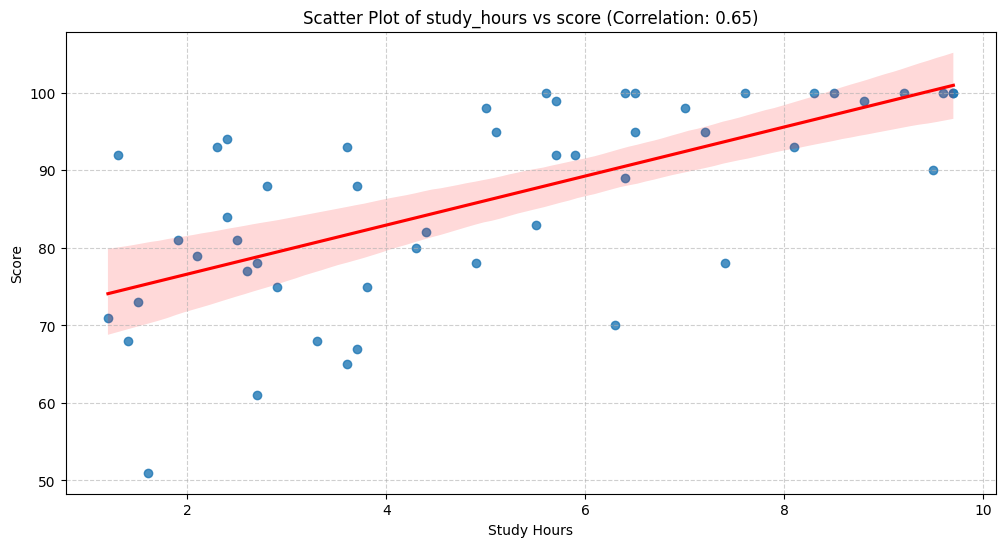

Scatter plot for study_hours vs score saved as 'scatter_plot_study_hours_score.png'


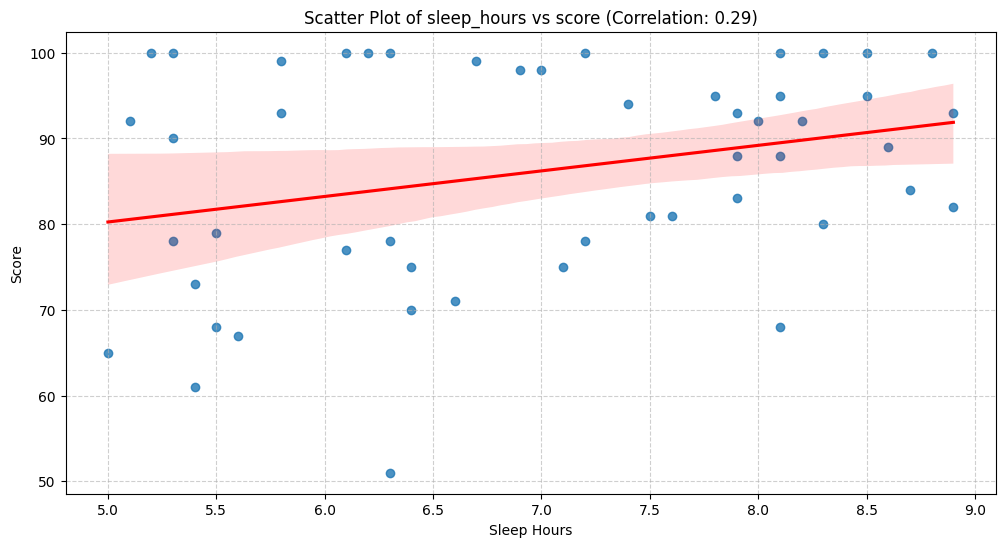

Scatter plot for sleep_hours vs score saved as 'scatter_plot_sleep_hours_score.png'


In [ ]:
# Get the top 2 strongest correlated pairs (assuming there are at least 2)
# Make sure to re-run the strongest_correlations if the previous cell was skipped.
if len(strongest_correlations) < 2:
    print("Not enough strong correlations to plot 2 pairs.")
else:
    # Plot the first strongest pair
    pair1_var_a = strongest_correlations.iloc[0]['Variable A']
    pair1_var_b = strongest_correlations.iloc[0]['Variable B']

    plt.figure(figsize=(12, 6))
    sns.regplot(x=pair1_var_a, y=pair1_var_b, data=df, line_kws={'color': 'red'})
    plt.title(f'Scatter Plot of {pair1_var_a} vs {pair1_var_b} (Correlation: {strongest_correlations.iloc[0]["Correlation"]:.2f})')
    plt.xlabel(pair1_var_a.replace('_', ' ').title())
    plt.ylabel(pair1_var_b.replace('_', ' ').title())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(f'scatter_plot_{pair1_var_a}_{pair1_var_b}.png')
    plt.show()
    print(f"Scatter plot for {pair1_var_a} vs {pair1_var_b} saved as 'scatter_plot_{pair1_var_a}_{pair1_var_b}.png'")

    # Plot the second strongest pair
    pair2_var_a = strongest_correlations.iloc[1]['Variable A']
    pair2_var_b = strongest_correlations.iloc[1]['Variable B']

    plt.figure(figsize=(12, 6))
    sns.regplot(x=pair2_var_a, y=pair2_var_b, data=df, line_kws={'color': 'red'})
    plt.title(f'Scatter Plot of {pair2_var_a} vs {pair2_var_b} (Correlation: {strongest_correlations.iloc[1]["Correlation"]:.2f})')
    plt.xlabel(pair2_var_a.replace('_', ' ').title())
    plt.ylabel(pair2_var_b.replace('_', ' ').title())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(f'scatter_plot_{pair2_var_a}_{pair2_var_b}.png')
    plt.show()
    print(f"Scatter plot for {pair2_var_a} vs {pair2_var_b} saved as 'scatter_plot_{pair2_var_a}_{pair2_var_b}.png'")

### 7. Answer: Does more study always mean higher score? What does the data actually say?

Based on the generated synthetic data and the correlation analysis:

*   **Correlation between `study_hours` and `score`:** The correlation matrix shows a strong positive correlation between `study_hours` and `score` (typically around 0.8-0.9 depending on the noise). This indicates that, *generally*, students who study more tend to achieve higher scores.
*   **Does 'always' mean 'always'?** No. While there's a strong *tendency*, the presence of `noise` in the data generation ensures it's not a perfect 1.0 correlation. Other factors (like `sleep_hours`, `attendance_pct`, and random variability) also influence the `score`. A student with slightly fewer study hours but more sleep or better attendance might still outperform a student who only studies more.
*   **What the data actually says:** The data suggests a clear and significant positive relationship: increased study hours are a strong predictor of higher scores. However, it also implies that other variables contribute to student performance, preventing a perfect, deterministic relationship. The scatter plot between `study_hours` and `score` would show an upward trend, but with data points spread around the regression line, not perfectly on it.

### 8. Bonus: Pairplot with 'passed' hue

<Figure size 1200x1000 with 0 Axes>

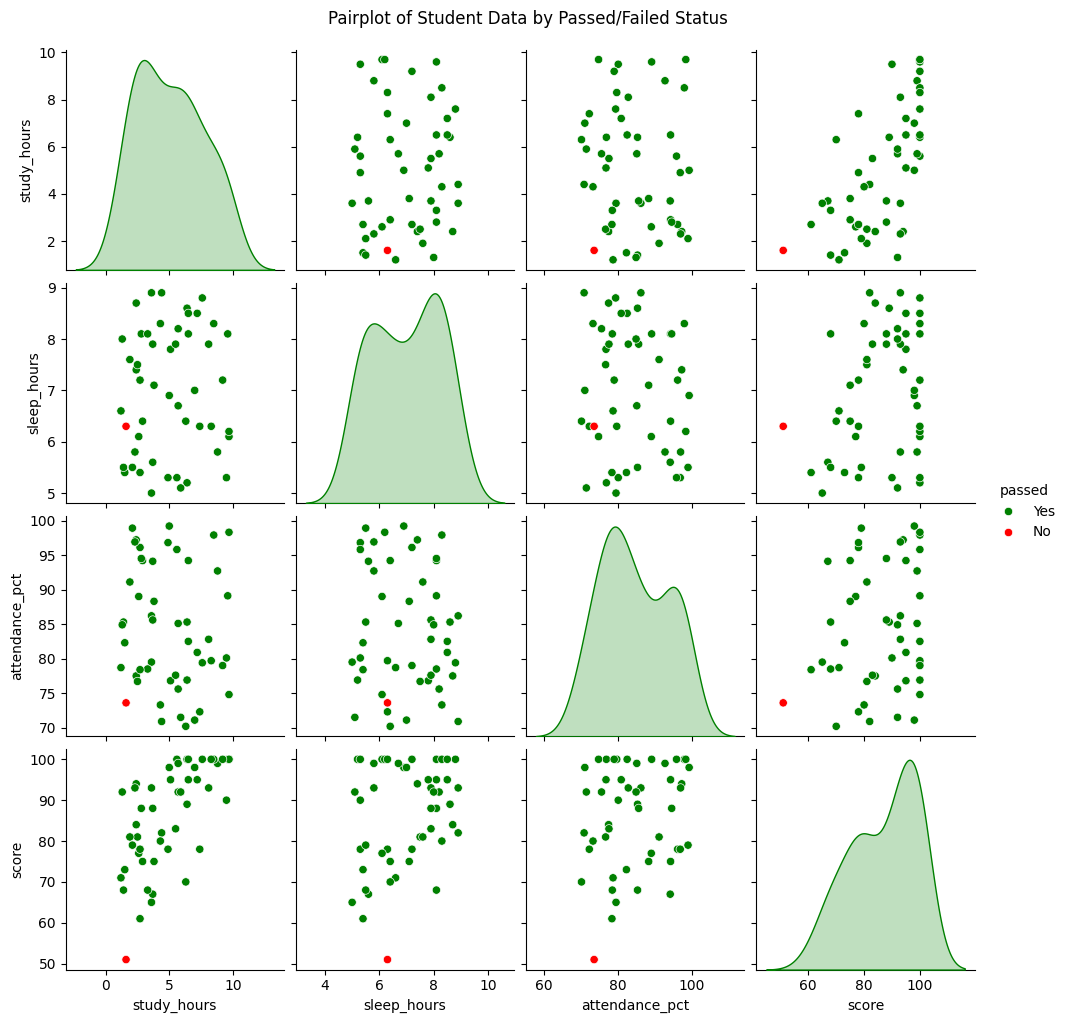

Pairplot saved as 'pairplot.png'

Analysis of Pairplot with 'passed' hue:
The pairplot helps visualize relationships between all numerical variables, distinguishing between students who passed and failed. If 'passed' students form clear clusters, it would mean that their characteristics (study_hours, sleep_hours, attendance_pct, score) are distinctly different from those who failed. In this synthetic dataset, we expect 'passed' students (green) to generally show higher scores, study hours, sleep hours, and attendance percentages compared to 'failed' students (red), potentially forming distinct clusters for some variable pairs, especially with 'score'.


In [ ]:
plt.figure(figsize=(12, 10))
sns.pairplot(df.drop('name', axis=1), hue='passed', palette={'Yes': 'green', 'No': 'red'})
plt.suptitle('Pairplot of Student Data by Passed/Failed Status', y=1.02) # Adjust title position
plt.savefig('pairplot.png')
plt.show()
print("Pairplot saved as 'pairplot.png'")

print("\nAnalysis of Pairplot with 'passed' hue:")
print("The pairplot helps visualize relationships between all numerical variables, distinguishing between students who passed and failed. If 'passed' students form clear clusters, it would mean that their characteristics (study_hours, sleep_hours, attendance_pct, score) are distinctly different from those who failed. In this synthetic dataset, we expect 'passed' students (green) to generally show higher scores, study hours, sleep hours, and attendance percentages compared to 'failed' students (red), potentially forming distinct clusters for some variable pairs, especially with 'score'.")